This problem involves the Boston data set, which we saw in the lab
for this chapter. We will now try to predict per capita crime rate
using the other variables in this data set. In other words, per capita
crime rate is the response, and the other variables are the predictors

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv('Boston.csv')
data

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


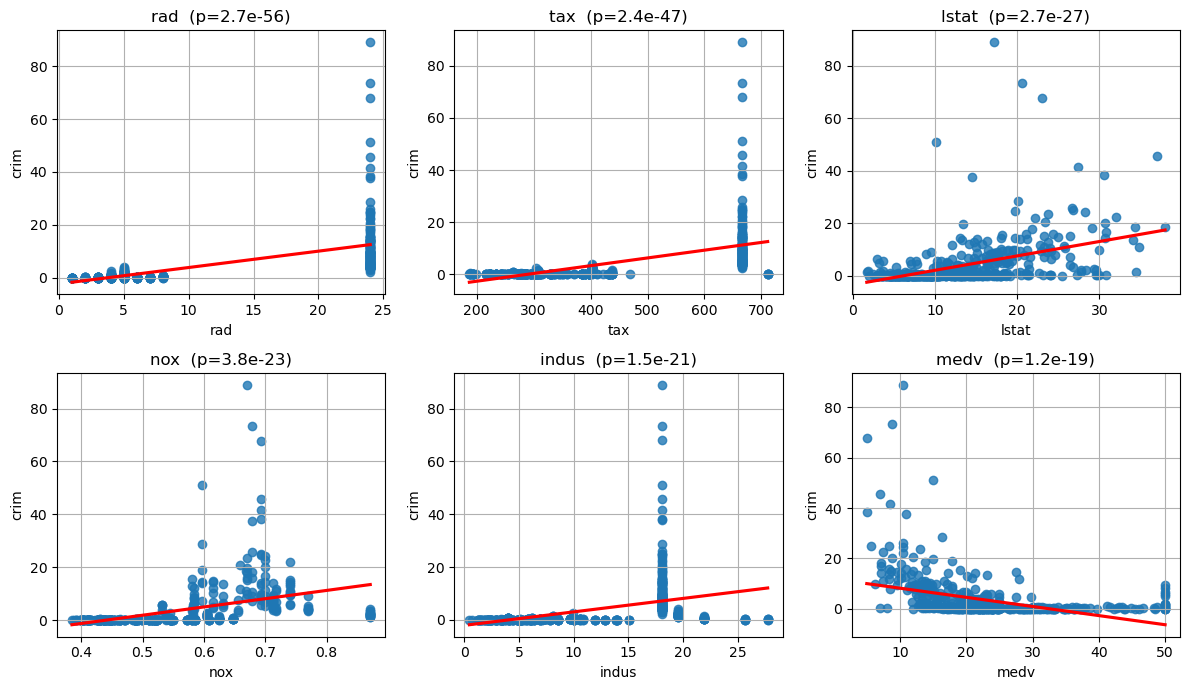

In [9]:
import seaborn as sns
import statsmodels.api as sm
y = data['crim']
predictors = data.columns.drop('crim')

rows = []
for c in predictors:
    m = sm.OLS(y, sm.add_constant(data[c])).fit()
    rows.append((c, float(m.pvalues[c])))
res = pd.DataFrame(rows, columns=['var','p']).sort_values('p')

top6 = res.head(6)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
for i, (v, p) in enumerate(top6.values):
    sns.regplot(x=v, y='crim', data=data, ax=axes[i], ci=None, line_kws={'color':'red'})
    axes[i].set_title(f'{v}  (p={p:.1e})')
    axes[i].set_xlabel(v)
    axes[i].set_ylabel('crim')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

lstat（percentage of lower status population）<br>

強烈正相關 (p ≈ 2.7e-27)，低社經地位人口比例高，犯罪率上升

medv（median value of owner-occupied homes）<br>

顯著負相關 (p ≈ 1.2e-19)，房價越高的地區，犯罪率越低


### (b)
Fit a multiple regression model to predict the response using
all of the predictors. Describe your results. For which predictors
can we reject the null hypothesis H0 : βj = 0

In [11]:
y = data['crim']
X = data.drop(columns=['crim'])

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           2.03e-56
Time:                        21:10:39   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.7784      7.082      1.946      0.0

In [13]:
significant_vars = model.pvalues[model.pvalues < 0.05].index.tolist()
significant_vars.remove('const') if 'const' in significant_vars else None

print("(p < 0.05):")
print(significant_vars)

(p < 0.05):
['zn', 'dis', 'rad', 'medv']


這四個變數的p<0.05，可以拒絕虛無假設H0

### (c)
How do your results from (a) compare to your results from (b)?
Create a plot displaying the univariate regression coefficients
from (a) on the x-axis, and the multiple regression coefficients
from (b) on the y-axis. That is, each predictor is displayed as a
single point in the plot. Its coefficient in a simple linear regres-
sion model is shown on the x-axis, and its coefficient estimate
in the multiple linear regression model is shown on the y-axis.

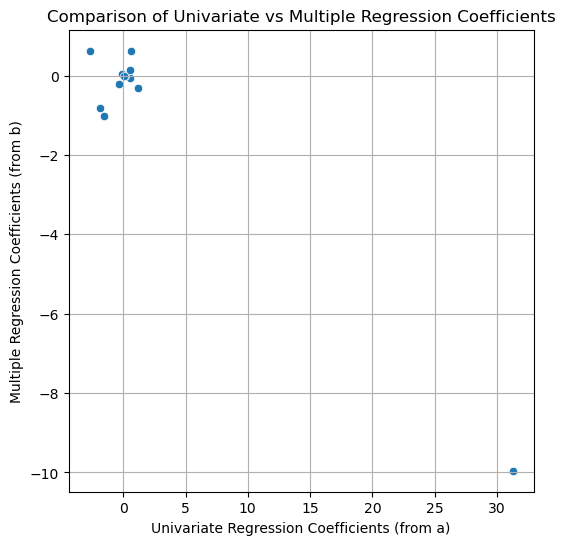

In [16]:
y = data['crim']
predictors = data.columns.drop('crim')

#nivariate regression 
uni_coefs = []
for c in predictors:
    model = sm.OLS(y, sm.add_constant(data[c])).fit()
    uni_coefs.append(model.params[c])
uni_coefs = pd.Series(uni_coefs, index=predictors)

#multiple regression 
X = sm.add_constant(data[predictors])
multi_model = sm.OLS(y, X).fit()
multi_coefs = multi_model.params.drop('const')

plt.figure(figsize=(6,6))
sns.scatterplot(x=uni_coefs, y=multi_coefs)
plt.xlabel("Univariate Regression Coefficients (from a)")
plt.ylabel("Multiple Regression Coefficients (from b)")
plt.title("Comparison of Univariate vs Multiple Regression Coefficients")
plt.grid(True)
plt.show()

### (d)
Is there evidence of non-linear association between any of the
predictors and the response? To answer this question, for each
predictor X, fit a model of the form
Y = β0 + β1X + β2X2 + β3X3 + ϵ.

有非線性關係的變數： ['indus', 'nox', 'age', 'dis']


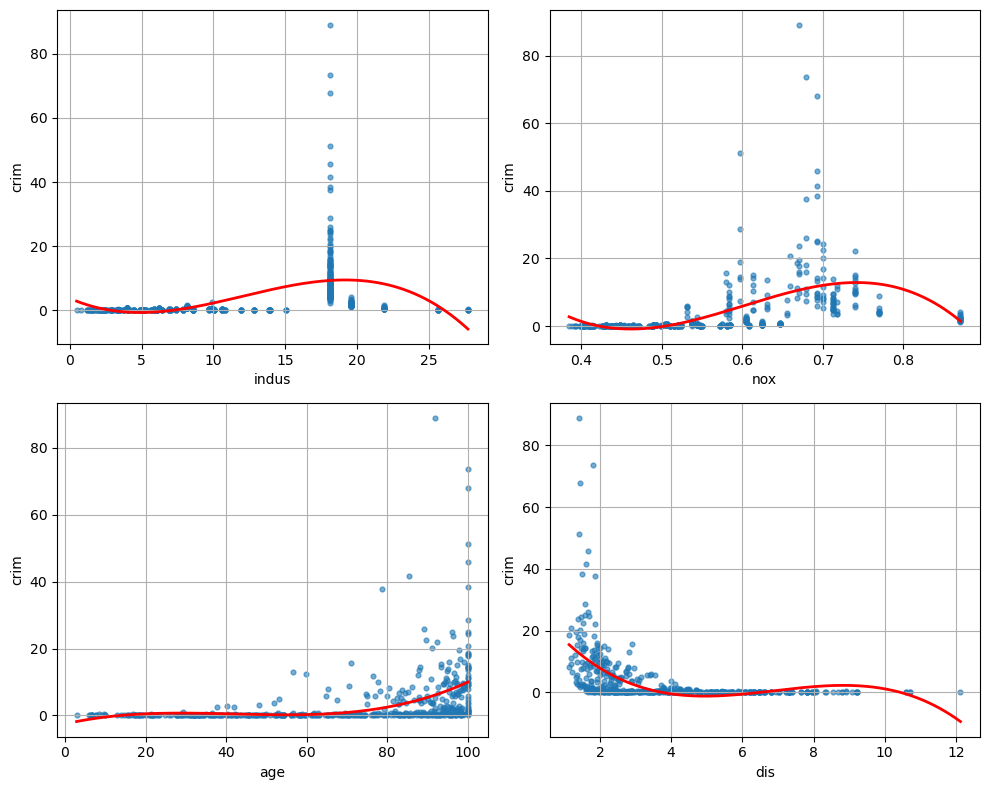

In [20]:
nonlinear_vars = []

for col in predictors:
    X = pd.DataFrame({'X': data[col], 'X2': data[col]**2, 'X3': data[col]**3})
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    if (model.pvalues['X2'] < 0.05) or (model.pvalues['X3'] < 0.05):
        nonlinear_vars.append(col)

print("有非線性關係的變數：", nonlinear_vars[:4])

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for i, var in enumerate(nonlinear_vars[:4]):
    x = data[var]
    xx = np.linspace(x.min(), x.max(), 300)
    X_pred = sm.add_constant(pd.DataFrame({'X': xx, 'X2': xx**2, 'X3': xx**3}))
    model = sm.OLS(y, sm.add_constant(pd.DataFrame({'X': x, 'X2': x**2, 'X3': x**3}))).fit()
    y_pred = model.predict(X_pred)

    axes[i].scatter(x, y, s=12, alpha=0.6)
    axes[i].plot(xx, y_pred, color='red', linewidth=2)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("crim")
    axes[i].grid(True)

for j in range(len(nonlinear_vars[:4]), 4):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()